In [401]:
import numpy as np
import scipy.integrate as integrate
import scipy.interpolate as interpolate
import matplotlib.pyplot as plt
from scipy.special import jn
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import cv2
from scipy.spatial import KDTree

In [402]:
def gaussian_2d(xy, amp, x0, y0, sigma_x, sigma_y):
    x, y = xy
    return amp * np.exp(-(((x - x0) ** 2) / (2 * sigma_x ** 2) + ((y - y0) ** 2) / (2 * sigma_y ** 2)))
  

def gaussian_fit(zdata,xdata,ydata):
    x, y = np.meshgrid(xdata, ydata)
    # Flatten the data for curve_fit
    xfit = x.ravel()
    yfit = y.ravel()
    zfit = zdata.ravel()
    # Estimate initial x0 and y0 based on the peak
    peak_index = np.unravel_index(np.argmax(zdata), zdata.shape)
    x0_guess = xdata[peak_index[1]]  # Corresponding x value
    y0_guess = ydata[peak_index[0]]  # Corresponding y value
    params_guess = (np.max(zdata),x0_guess,y0_guess,1,1)
    lower_bounds = [0, min(xdata), min(ydata), 0.1, 0.01]
    upper_bounds = [2000, max(xdata), max(ydata), 10, 10]
    # Fit the data
    popt, pcov = curve_fit(gaussian_2d, (xfit,yfit), zfit, p0=params_guess, bounds=(lower_bounds, upper_bounds), maxfev=10000)
    return popt

In [403]:
def gauss(x,a,mu,s):
    return a*np.exp(-((x-mu)**2)/(2*s**2))

def custom_dilation(image):
    output = np.zeros_like(image)
    rows, cols = image.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            neighborhood = image[r-1:r+2, c-1:c+2]
            output[r, c] = np.max(neighborhood)
    return output

def point_sparser(x,y,dist_threshold):
    points = np.column_stack((x, y))
    # Create a KDTree from the points
    tree = KDTree(points)
    # Create a boolean mask where points will be kept (True means keep)
    mask = np.ones(len(points), dtype=bool)
    # Loop over all points and remove one of the points that are too close
    for i in range(len(points)):
        if not mask[i]:  # If point i has already been removed, skip it
            continue       
        # Query for all points within the threshold distance (including the point itself)
        neighbors = tree.query_ball_point(points[i], dist_threshold)     
        # Remove the point itself from the neighbors list (i is always in its own neighborhood)
        neighbors.remove(i)
        # If there are any neighbors, remove one of them (mark it for removal)
        for neighbor in neighbors:
            if mask[neighbor]:  # If the neighbor is still available (not removed)
                mask[neighbor] = False  # Remove the neighbor (mark as False)
    # Apply the mask to keep only points that are not too close to others
    filtered_points = points[mask]
    x_filtered = filtered_points[:, 0]
    y_filtered = filtered_points[:, 1]
    return x_filtered, y_filtered

def super_locs(image,intensity_threshold,dist_threshold):
    # Threshold finder
    if intensity_threshold == 'auto':
        histogram, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])
        bins = np.delete(bins, -1)
        params, covariance = curve_fit(gauss, bins, histogram)
        threshold = params[1] + 4*params[2]

    # Max finder
    image_t = image.copy()
    image_t[image_t < intensity_threshold] = 0
    dilated_image = custom_dilation(image_t)
    image_f = image.copy()
    image_f[image_f != dilated_image] = 0
    y_peaks, x_peaks = np.nonzero(image_f)

    # Delete points that are too close to each other
    posx, posy = point_sparser(x_peaks,y_peaks,dist_threshold)

    # Super loc
    number_of_max = len(posx)
    x_loc = []
    y_loc = []
    minus_step = 15
    plus_step = minus_step + 1
    #print(number_of_max)
    for i in range(number_of_max):
        #if i == 100:
        #print(f"Max pixel position : {round(posx[i]),round(posy[i])}")
        x_idx = np.arange(round(posx[i]-minus_step),round(posx[i]+plus_step))
        y_idx = np.arange(round(posy[i]-minus_step),round(posy[i]+plus_step))
        try:
            center_part = image[y_idx, :][:, x_idx]
            # plt.figure()
            # plt.imshow(center_part,extent=[min(x_idx), max(x_idx), min(y_idx), max(y_idx)],
            #            aspect='equal', origin='lower')
            # plt.xticks(np.linspace(min(x_idx), max(x_idx),5))
            params = gaussian_fit(center_part,x_idx, y_idx)
            # plt.figure()
            # plt.imshow()
            #print(f"Super localized positions : {params[1], params[2]}")
            x_loc.append(params[1])
            y_loc.append(params[2])
        finally:
            continue
        
    return x_loc, y_loc
    


# image_path = 'Simulated_single_image_UINT8.jpg'
# image = cv2.imread(image_path)
# image = image[:,:,0]

# x, y = super_locs(image)
# print(x)
# print(y)

In [404]:
def video_to_3d_array(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Unable to open video: {video_path}")    
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break  # Stop when there are no more frames
        # Convert BGR to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)  
    cap.release()
    # Convert the list of frames to a NumPy array
    video_array = np.array(frames, dtype=np.uint8)
    return video_array[:,:,:,0]

# Example usage
video_path = "video_to_start_coding_2.avi"  # Replace with your video file path
video_array = video_to_3d_array(video_path)
print("Video shape:", video_array.shape)  # Output: (frames, height, width, channels)

Video shape: (136, 1080, 1440)


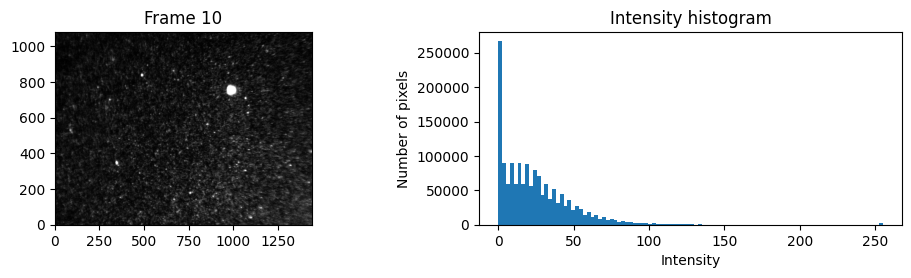

Number of localizations : 25


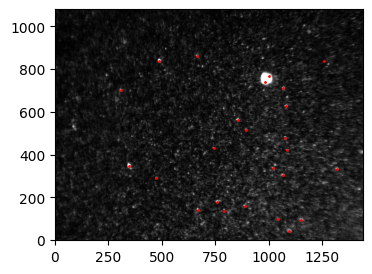

In [406]:
frame_idx = 10
image = video_array[frame_idx,:,:]

plt.figure(figsize=(12, 2.5))
plt.subplot(1, 2, 1)
plt.title(f'Frame {frame_idx}')
plt.imshow(image, cmap='gray', origin='lower', aspect='equal')
plt.subplot(1, 2, 2)
plt.title('Intensity histogram')
plt.hist(image.flatten(), bins=100)
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')
plt.show()

x, y = super_locs(image,intensity_threshold=250,dist_threshold=50)
print(f"Number of localizations : {len(x)}")

plt.figure(figsize=(5,3))
plt.imshow(image, cmap='gray',origin='lower', aspect='equal')
plt.scatter(x, y, color='r', s=1)
plt.show()